# About
Authors: Shahar and Shlomi

[Github](https://github.com/shachar700/DataAnalysis_ElectricVehicles)

[Presentation](https://docs.google.com/presentation/d/16cQc9AChOSBG5RZ8JWvXcKvgd7OXHD_7hOMkyVqcmno/edit?usp=sharing)



Questions:

- Top 7 companies with total amount of vehicles
- Top 7 models with total amount of vehicles
- Popular companies in each county
- Popular models in each county

- Vehicles per state
- Vehicles per county
- Vehicles per city
- Vehicles per electric utility

- Vehicles per legistrative district (handle na values) **
- Electric Range per model (handle na values) **
- graph Make and electric range

# Comments
* turn dtype to categories where needed

* handle missing values: drop rows

* split categories and turn them to binary values.
dummies for Electric Utility and handle
higher index to dummies

Column Name -	Description

VIN (1-10) - First 10 characters of the Vehicle Identification Number.

County - The county where the vehicle is registered or located.

City - The city where the vehicle is registered or located.

State - The U.S. state abbreviation (e.g., WA for Washington).

Postal Code - ZIP/postal code of the vehicle's location.

Model Year - The year the vehicle was manufactured.

Make - The manufacturer (e.g., Tesla, Nissan).

Model - The specific model of the car (e.g., Model 3, Leaf).

Electric Vehicle Type - Type of EV (Battery Electric Vehicle (BEV), Plug-in Hybrid Electric Vehicle (PHEV), etc.).

Clean Alternative Fuel Vehicle (CAFV) Eligibility - Indicates whether the vehicle qualifies under CAFV rules.

Electric Range - How many miles the vehicle can travel on electricity alone.

Base MSRP - Manufacturer's Suggested Retail Price at base level (starting price).

Legislative District - Legislative district associated with the vehicle's location.

DOL Vehicle ID - Department of Licensing Vehicle ID (state-assigned).

Vehicle Location - More detailed info about where the vehicle is located.

Electric Utility - The electric company servicing that area.

2020 Census Tract - Census tract identifier from the 2020 census (used for demographic/geographic analysis).

# Installs

# Libraries

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-process

In [ ]:
electric_vehicles_url = "https://raw.githubusercontent.com/shachar700/DataAnalysis_ElectricVehicles/refs/heads/main/data/Electric_Vehicle_Population_Data.csv"

def download_file(url, file_name):
  response = requests.get(url)
  if response.status_code == 200:
    with open(file_name, "wb") as file:
        file.write(response.content)
    print(f"Downloaded: {file_name}")

download_file(electric_vehicles_url, "Electric_Vehicle_Population_Data.csv")

Downloaded: Electric_Vehicle_Population_Data.csv


In [ ]:
df = pd.read_csv("/content/Electric_Vehicle_Population_Data.csv")
df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB6K,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,101250425,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGAEE5M,Yakima,Selah,WA,98942.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,224162858,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
2,5YJSA1E65N,Yakima,Granger,WA,98932.0,2022,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,187279214,POINT (-120.1871 46.33949),PACIFICORP,5.307700e+10
3,5YJ3E1EBXN,King,Bellevue,WA,98004.0,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,41.0,219428079,POINT (-122.1872 47.61001),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
4,JM3KKEHA8S,Thurston,Yelm,WA,98597.0,2025,MAZDA,CX-90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,0.0,2.0,277791643,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246137 entries, 0 to 246136
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         246137 non-null  object 
 1   County                                             246133 non-null  object 
 2   City                                               246133 non-null  object 
 3   State                                              246137 non-null  object 
 4   Postal Code                                        246133 non-null  float64
 5   Model Year                                         246137 non-null  int64  
 6   Make                                               246137 non-null  object 
 7   Model                                              246137 non-null  object 
 8   Electric Vehicle Type                              246137 non-null  object

In [ ]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,246133.000000,246137.000000,246120.000000,246120.000000,245597.000000,2.461370e+05,2.461330e+05
mean,98179.658481,2021.535698,44.872192,746.606188,28.871831,2.374324e+08,5.297685e+10
std,2494.101983,2.999144,82.913952,6987.233456,14.895938,6.719158e+07,1.580103e+09
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,17.000000,2.083391e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,0.000000,32.000000,2.548460e+08,5.303303e+10
75%,98375.000000,2024.000000,37.000000,0.000000,42.000000,2.717319e+08,5.305307e+10
max,99577.000000,2026.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.602100e+10


In [ ]:
dummies = df["Electric Utility"].str.get_dummies("|")
# print(dummies.columns.tolist())
# df = pd.concat([df, dummies], axis=1)
dummies.head(3)
display(dummies.sum().sort_values())
df.head(3)

,0
"ALDER MUTUAL LIGHT CO, INC",3
"NESPELEM VALLEY ELEC COOP, INC",3
CITY OF COULEE DAM - (WA),10
CITY OF SUMAS - (WA),11
CITY OF CHEWELAH,13
...,...
PUD NO 1 OF CLARK COUNTY - (WA),14787
CITY OF SEATTLE - (WA),41822
BONNEVILLE POWER ADMINISTRATION,49409
CITY OF TACOMA - (WA),146090


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB6K,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,101250425,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGAEE5M,Yakima,Selah,WA,98942.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,224162858,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
2,5YJSA1E65N,Yakima,Granger,WA,98932.0,2022,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,187279214,POINT (-120.1871 46.33949),PACIFICORP,5.307700e+10


In [ ]:
display(df.isnull().sum())

,0
VIN (1-10),0
County,4
City,4
State,0
Postal Code,4
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [ ]:
# df['Make'].value_counts()

In [ ]:
# df[['Make','Model']].value_counts()

## drop unused columns

In [ ]:
print("Shape Before", df.shape)
df = df.drop(columns=["Base MSRP", "Vehicle Location", "DOL Vehicle ID", "2020 Census Tract"])
print("Shape After", df.shape)

Shape Before (246137, 17)
Shape After (246137, 13)


## Handle missing data

In [ ]:
display(df[df["County"].isna()])
print("Shape before", df.shape)
df = df.dropna(subset=["County"])
print("Shape After", df.shape)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
699,WBAJA9C50K,NaN,NaN,AE,NaN,2019,BMW,530E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,16.0,NaN,NaN
214506,7JRBR0FM0N,NaN,NaN,BC,NaN,2022,VOLVO,S60,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,22.0,NaN,NaN
233134,5YJXCAE24H,NaN,NaN,BC,NaN,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,NaN,NaN
244288,5YJ3E1EB2M,NaN,NaN,NS,NaN,2021,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,NaN,NaN


Shape before (246137, 13)
Shape After (246133, 13)


# Vehicles per state
Conclusion: as most of the data was collected in WA the df shows they have the most vehicles (235198!), and followed by CA (but with only 112 vehicles)
Thus we can conclude that any vehicle not in WA is an outlier

<ipython-input-12-2662928974>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Count", y="State", data=vehicles_per_state, palette="Blues_d")


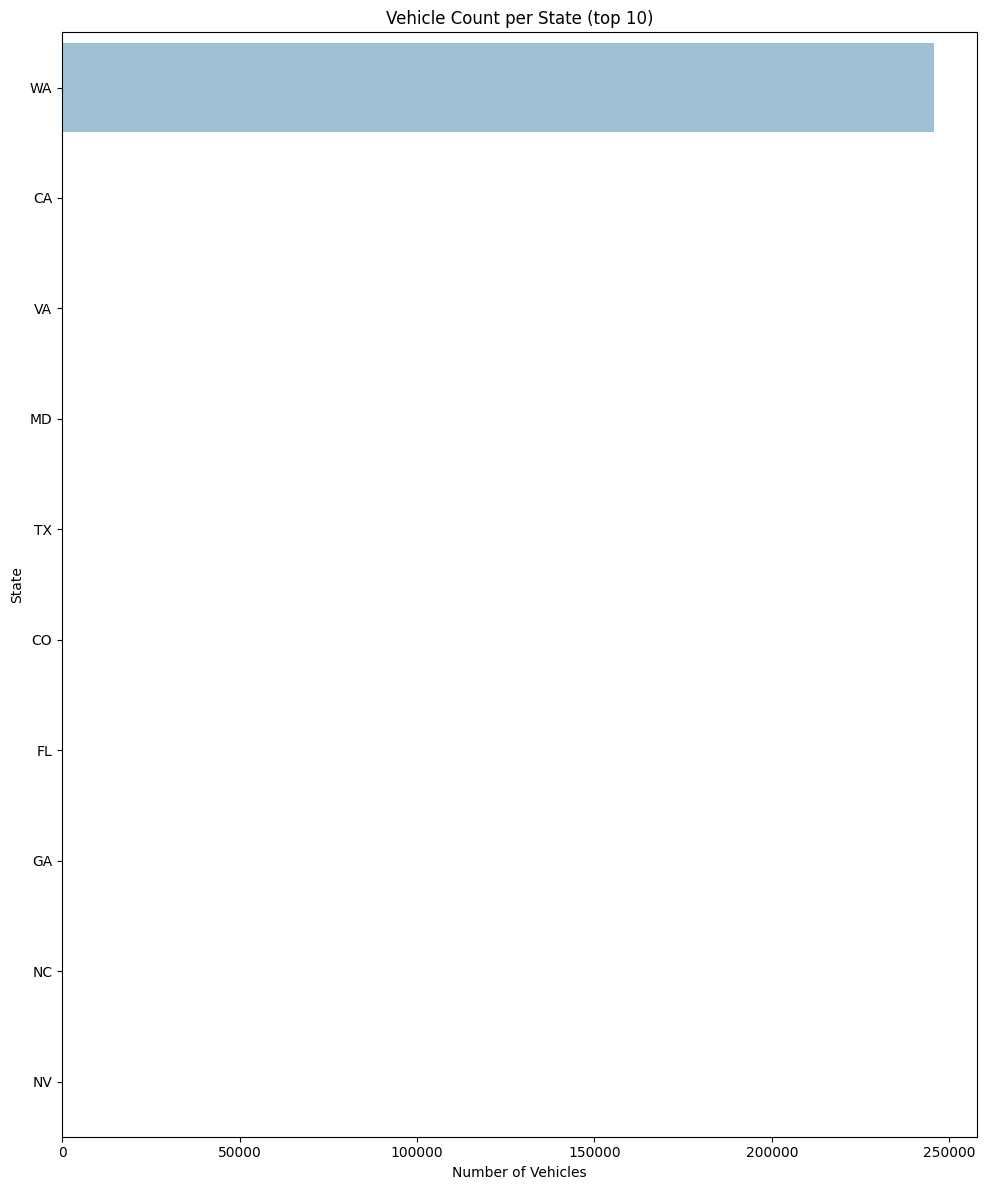

In [ ]:
vehicles_per_state = df.groupby(by="State").size().reset_index(name="Count")

vehicles_per_state = vehicles_per_state.sort_values("Count", ascending=False).head(10)

plt.figure(figsize=(10, 12))
sns.barplot(x="Count", y="State", data=vehicles_per_state, palette="Blues_d")

plt.title("Vehicle Count per State (top 10)")
plt.xlabel("Number of Vehicles")
plt.ylabel("State")
plt.tight_layout()
plt.show()


<ipython-input-13-1672476108>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Count", y="State", data=vehicles_per_state, palette="Blues_d")


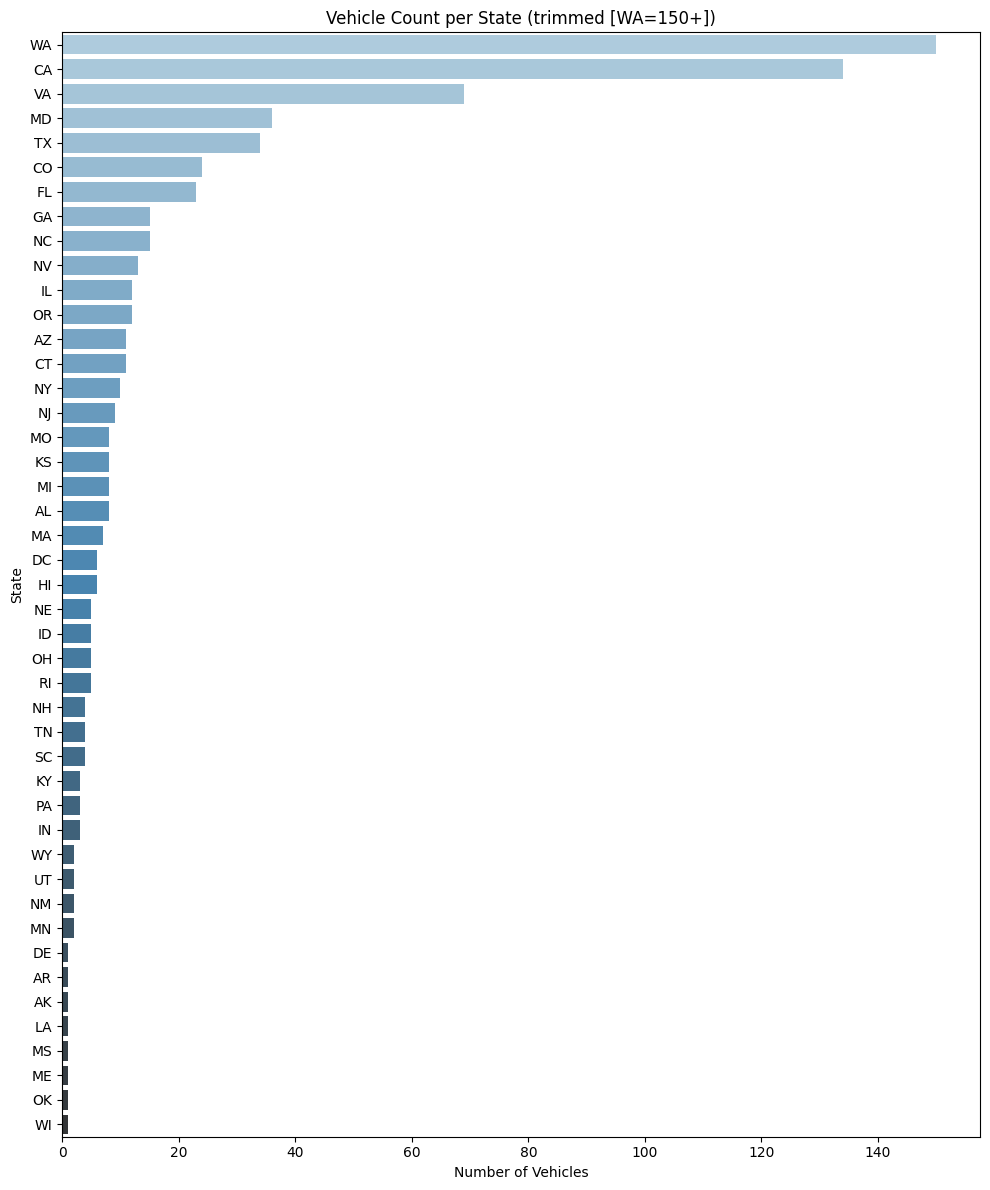

In [ ]:
vehicles_per_state = df.groupby(by="State").size().reset_index(name="Count")
vehicles_per_state = vehicles_per_state.sort_values("Count", ascending=False)
vehicles_per_state.loc[vehicles_per_state["State"] == "WA", "Count"] = 150

plt.figure(figsize=(10, 12))
sns.barplot(x="Count", y="State", data=vehicles_per_state, palette="Blues_d")

plt.title("Vehicle Count per State (trimmed [WA=150+])")
plt.xlabel("Number of Vehicles")
plt.ylabel("State")
plt.tight_layout()
plt.show()


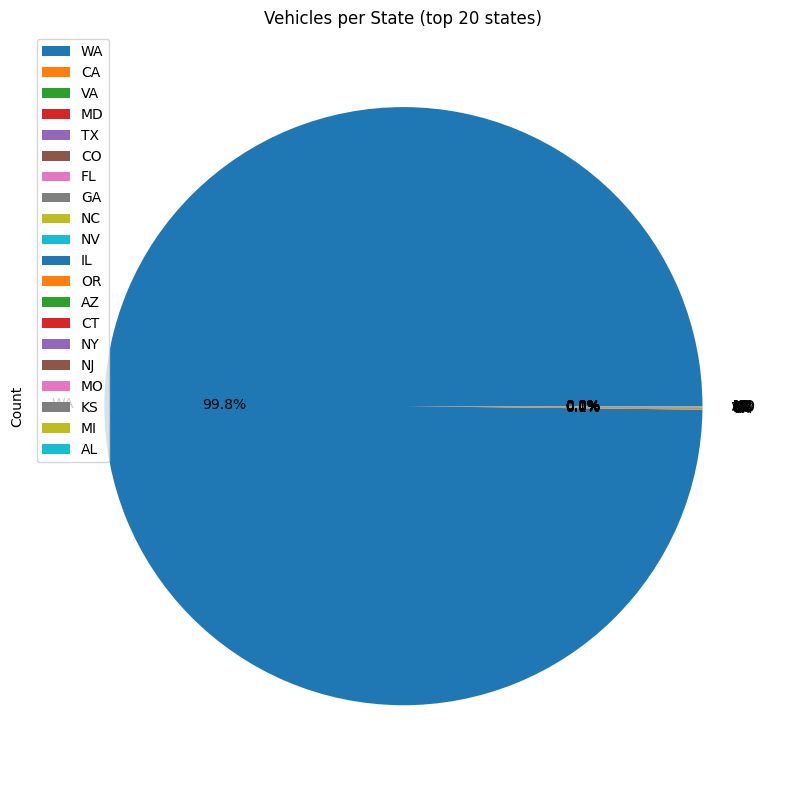

In [ ]:
vehicles_per_state = df.groupby(by="State").size().reset_index(name="Count")
vehicles_per_state = vehicles_per_state.sort_values("Count", ascending=False).head(20)

# Set the index to "State" so pie chart labels use it
vehicles_per_state.set_index("State")["Count"].plot.pie(
    autopct='%1.1f%%',
    figsize=(8, 8),
    title="Vehicles per State (top 20 states)",
    legend=True
)

plt.tight_layout()
plt.show()


# Vehicles per WA county

Conclusion: King county has the most (118711) by a large margin, followed by Snohomish
Thus we can conclude that any vehicle not in King county is an outlier

,County,Count
99,King,123557
180,Snohomish,30203
149,Pierce,20254
39,Clark,14810
194,Thurston,8938
101,Kitsap,8232
183,Spokane,6843
209,Whatcom,5952
18,Benton,3220
178,Skagit,2800


<ipython-input-15-1577617489>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vehicles_per_county, x='Count', y='County', palette='YlOrRd')


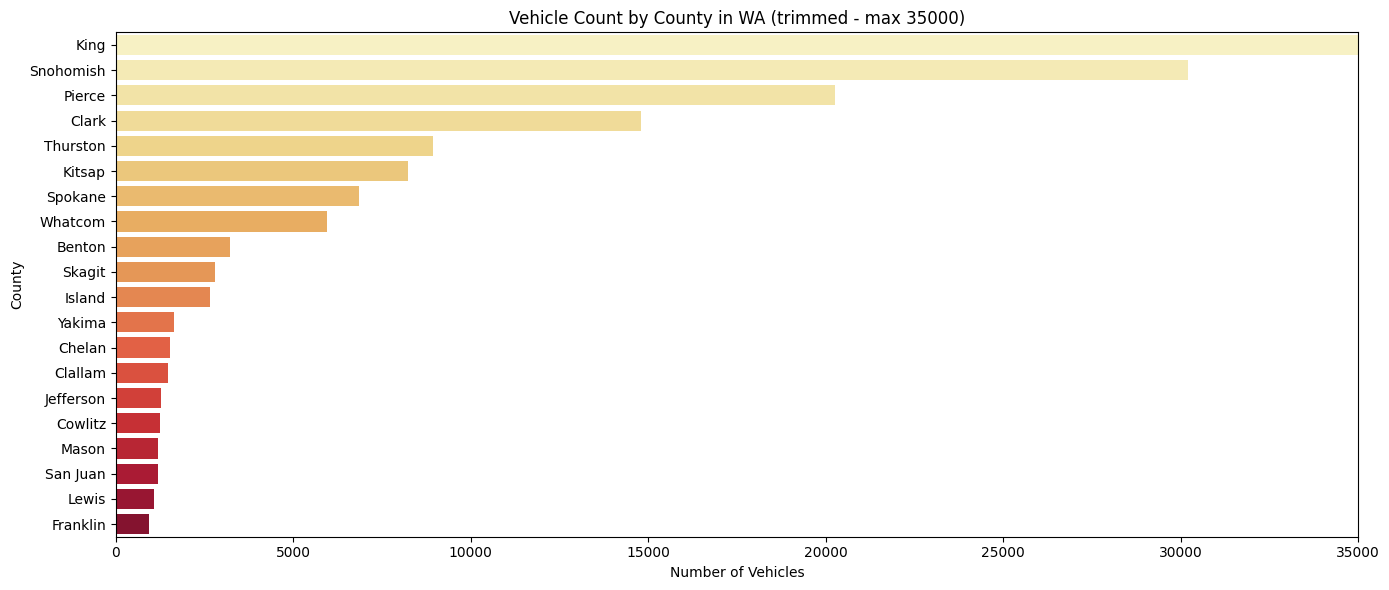

<ipython-input-15-1577617489>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vehicles_per_county, x='Count', y='County', palette='YlOrRd')


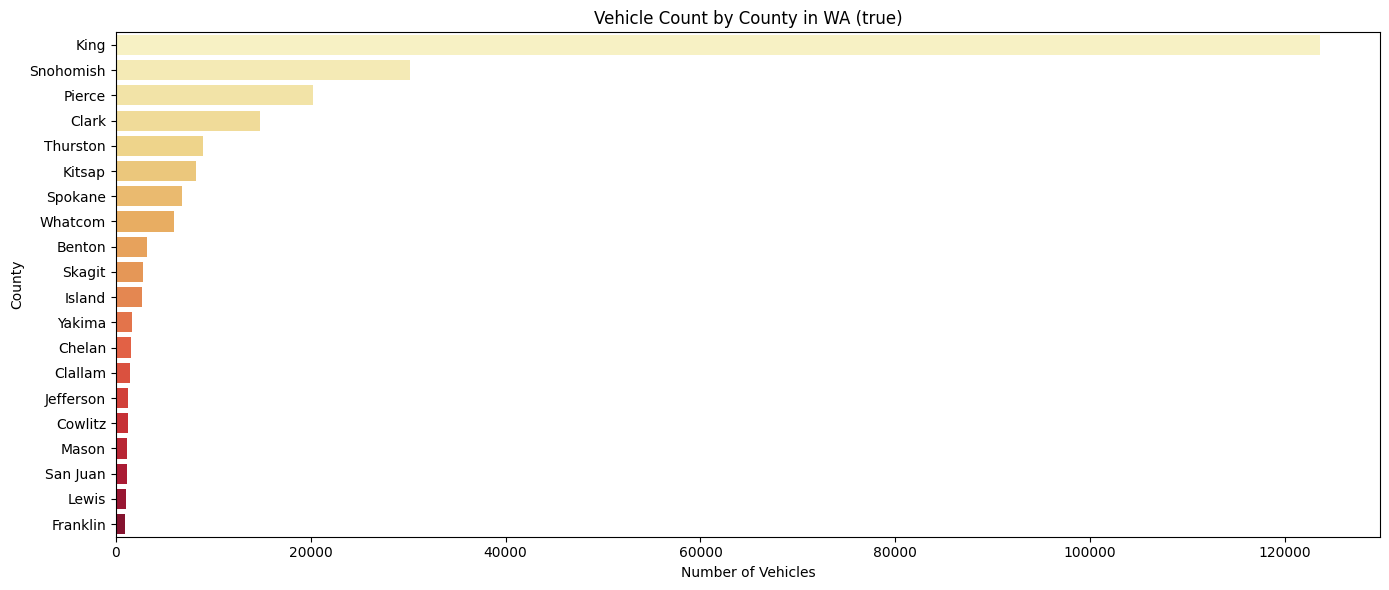

In [ ]:
filtered_df = df[ df["State"] == 'WA']

vehicles_per_county = df.groupby(by="County").size().reset_index(name="Count")
vehicles_per_county = vehicles_per_county.sort_values("Count", ascending=False)
vehicles_per_county = vehicles_per_county.head(n=20)

display(vehicles_per_county)
maxVal = 35000

plt.figure(figsize=(14, 6))
sns.barplot(data=vehicles_per_county, x='Count', y='County', palette='YlOrRd')
plt.xlabel('Number of Vehicles')
plt.ylabel('County')
plt.title(f'Vehicle Count by County in WA (trimmed - max {maxVal})')
plt.xlim(0, maxVal)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=vehicles_per_county, x='Count', y='County', palette='YlOrRd')
plt.xlabel('Number of Vehicles')
plt.ylabel('County')
plt.title(f'Vehicle Count by County in WA (true)')
plt.tight_layout()
plt.show()

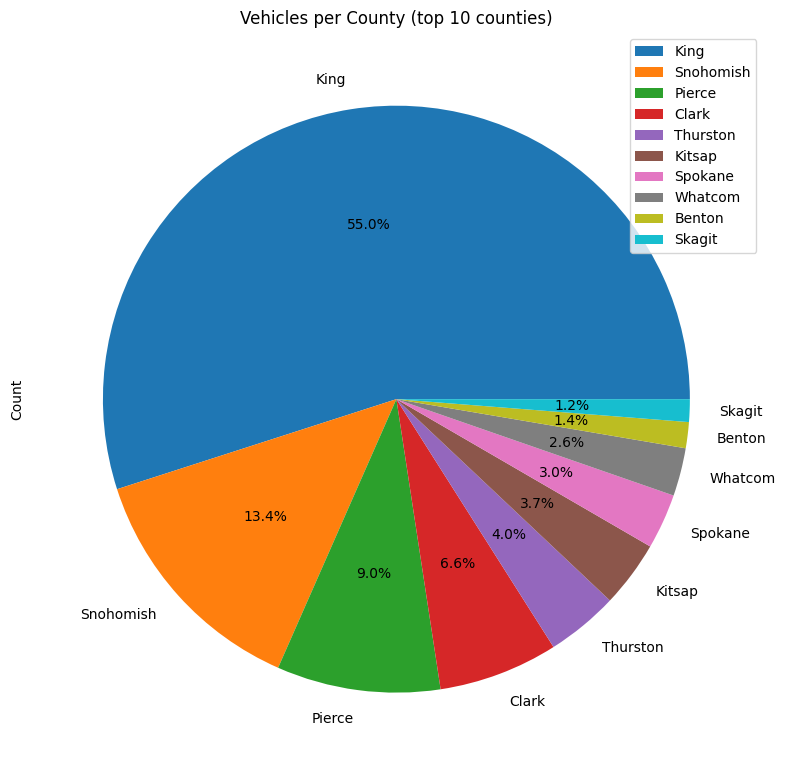

In [ ]:
filtered_df = df[ df["State"] == 'WA']
vehicles_per_county = filtered_df.groupby(by="County").size().reset_index(name="Count")
vehicles_per_county = vehicles_per_county.sort_values("Count", ascending=False).head(10)

# Set the index to "State" so pie chart labels use it
vehicles_per_county.set_index("County")["Count"].plot.pie(
    autopct='%1.1f%%',
    figsize=(8, 8),
    title="Vehicles per County (top 10 counties)",
    legend=True
)

plt.tight_layout()
plt.show()


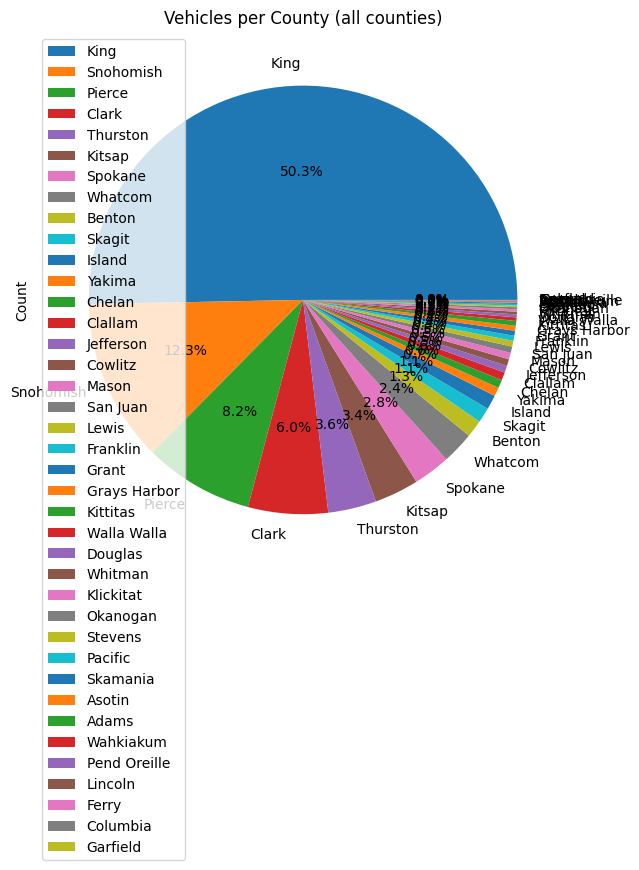

In [ ]:
filtered_df = df[ df["State"] == 'WA']
vehicles_per_county = filtered_df.groupby(by="County").size().reset_index(name="Count")
vehicles_per_county = vehicles_per_county.sort_values("Count", ascending=False)

# Set the index to "State" so pie chart labels use it
vehicles_per_county.set_index("County")["Count"].plot.pie(
    autopct='%1.1f%%',
    figsize=(8, 8),
    title="Vehicles per County (all counties)",
    legend=True
)

plt.tight_layout()
plt.show()


# Removing outliers

In [ ]:
filtered_df = df[ (df["State"] == 'WA') | (df["County"] == 'King')]
# filtered_df["City"] = filtered_df["City"].astype("category")
# filtered_df["Make"] = filtered_df["Make"].astype("category")
# filtered_df["Model"] = filtered_df["Model"].astype("category")

# Most popular vehicle per city
Conclusion: Tesla is the most popular in the top 20 cities with the most vehicles

In [ ]:
def vehicles_per_feature(feature):
  make_df = filtered_df.pivot_table(
    index=feature,
    columns="Make",
    values="Model",
    aggfunc="count",
    fill_value=0
  )

  # only the top 5 makers
  top_makes = make_df.sum(axis=0).nlargest(5).index
  make_df_top_makes = make_df.loc[:, top_makes]
  # only the top 20 of that feature
  top_20 = make_df_top_makes.sum(axis=1).nlargest(20).index
  make_df_top20 = make_df_top_makes.loc[top_20]

  make_df_filtered_pcts = make_df_top20.div(make_df_top20.sum(axis="columns"), axis="index")
  # display(make_df_filtered_pcts)
  make_df_filtered_pcts.plot.bar(stacked=True)

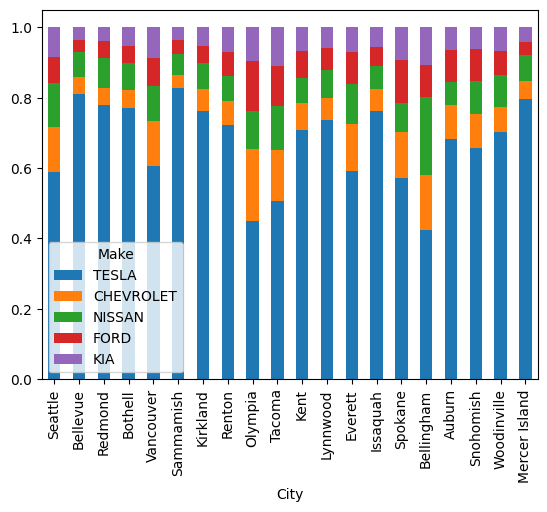

In [ ]:
vehicles_per_feature("City")

# Vehicles per electric utility
Conclusion: We see that 'Puget Sound Energy Inc' is the utility that service the most vehicles, followed closly by 'City of Tacoma'

,count
Electric Utility,
PUGET SOUND ENERGY INC,146779
CITY OF TACOMA - (WA),146090
BONNEVILLE POWER ADMINISTRATION,49409
CITY OF SEATTLE - (WA),41822
PUD NO 1 OF CLARK COUNTY - (WA),14787
PENINSULA LIGHT COMPANY,12964
PUD NO 1 OF WHATCOM COUNTY,5952
AVISTA CORP,4928
INLAND POWER & LIGHT COMPANY,4674


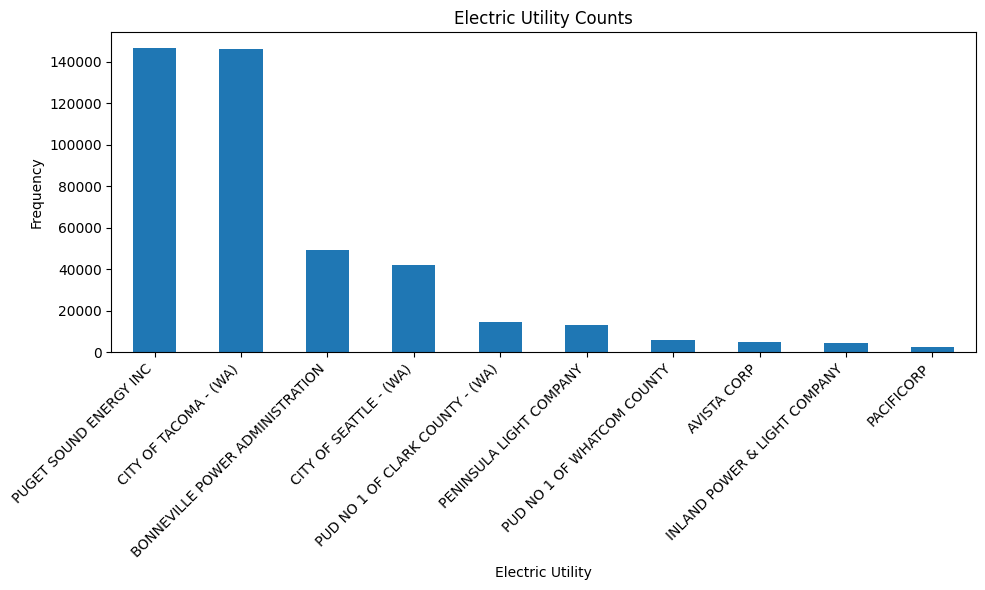

In [ ]:
utilities_df = filtered_df['Electric Utility'].str.split(r'\|+', regex=True).explode()
utility_counts = utilities_df.value_counts().head(10)
display(utility_counts)

plt.figure(figsize=(10, 6))
utility_counts.plot(kind='bar')
plt.title('Electric Utility Counts')
plt.xlabel('Electric Utility')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Vehicles per Electric Vehicle Type
Conclusion: ~80% of vehicles are Battery Electric Vehicle.
1 out of 5 vehicles is Plug-in Hybrid Vehicle

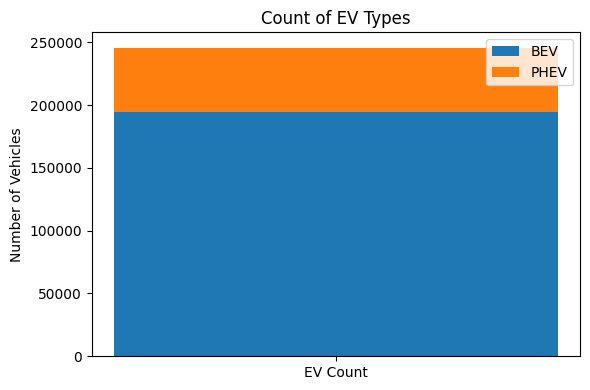

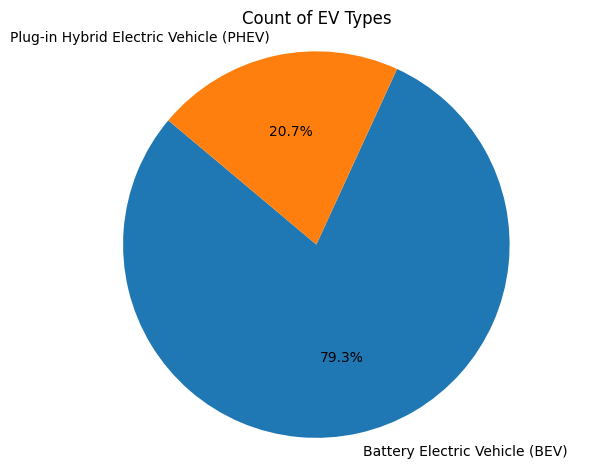

In [ ]:
counts = filtered_df['Electric Vehicle Type'].value_counts()

# Plot a stacked bar chart (single bar)
plt.figure(figsize=(6, 4))
plt.bar(['EV Count'], [counts.get('Battery Electric Vehicle (BEV)', 0)], label='BEV')
plt.bar(['EV Count'], [counts.get('Plug-in Hybrid Electric Vehicle (PHEV)', 0)], bottom=[counts.get('Battery Electric Vehicle (BEV)', 0)], label='PHEV')

# Add labels and legend
plt.title('Count of EV Types')
plt.ylabel('Number of Vehicles')
plt.legend()
plt.tight_layout()
plt.show()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Count of EV Types')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Models per Make (top 3 make)

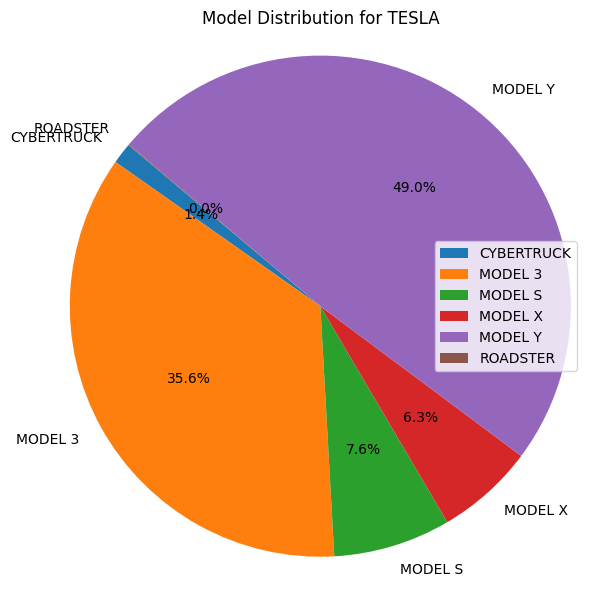

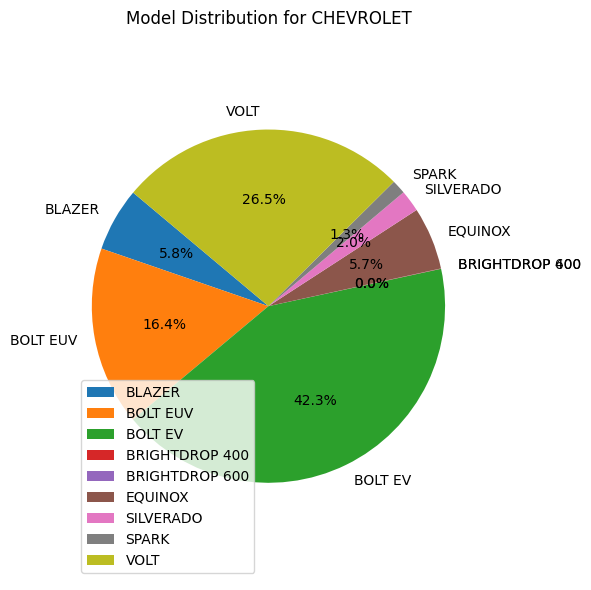

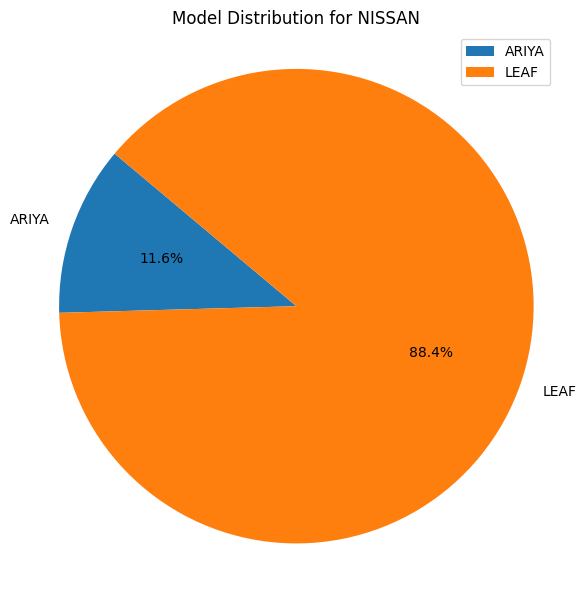

In [ ]:
models_per_make = df.groupby(["Make","Model"], dropna=False).size()

models_per_make = models_per_make.reset_index(name='Count')

top_makes = (
    models_per_make.groupby('Make')['Count']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

for make in top_makes:
    make_data = models_per_make[models_per_make['Make'] == make]
    plt.figure(figsize=(6, 6))
    plt.pie(make_data['Count'], labels=make_data['Model'], autopct='%1.1f%%', startangle=140)
    plt.title(f'Model Distribution for {make}')
    plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
    plt.tight_layout()
    plt.legend()
    plt.show()

# Vehicle count per make and model
Conclusion:
- Most vehicles are made by TESLA by a large margin followed by CHEVROLET and NISSAN.

- The top models are Model Y and 3 by Tesla in a large margin followed by Leaf made by Nissan.

<ipython-input-24-2617374952>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")


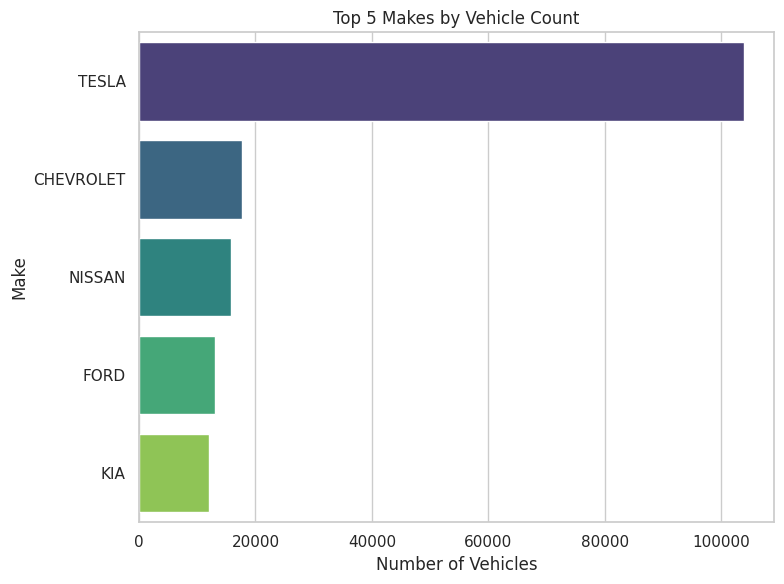

<ipython-input-24-2617374952>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models['Count'], y=top_models['Label'], palette="magma")


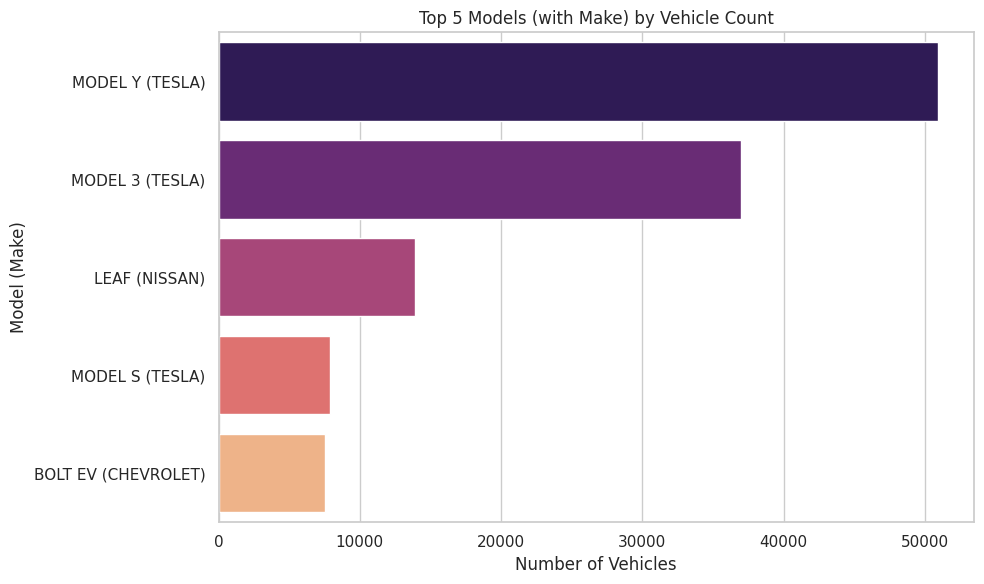

In [ ]:
# Set plot style
sns.set(style="whitegrid")

# Top 5 companies (makes)
top_makes = filtered_df['Make'].value_counts().nlargest(5)

# Group by both Model and Make to count unique (Model, Make) combinations
model_make_counts = filtered_df.groupby(['Model', 'Make']).size().reset_index(name='Count')

# Sort by count and get top 5
top_models = model_make_counts.sort_values(by='Count', ascending=False).head(5)

# Create label: "Model (Make)"
top_models['Label'] = top_models['Model'] + " (" + top_models['Make'] + ")"

# -------- First graph: Top 5 Companies --------
plt.figure(figsize=(8, 6))
sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")
plt.title('Top 5 Makes by Vehicle Count')
plt.xlabel('Number of Vehicles')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

# -------- Second graph: Top 5 Models (with Company) --------
plt.figure(figsize=(10, 6))
sns.barplot(x=top_models['Count'], y=top_models['Label'], palette="magma")
plt.title('Top 5 Models (with Make) by Vehicle Count')
plt.xlabel('Number of Vehicles')
plt.ylabel('Model (Make)')
plt.tight_layout()
plt.show()


# most popular make per county

In [ ]:
make_counts = filtered_df.groupby(['County', 'Make']).size().reset_index(name='Count')
top_makes_by_county = make_counts.sort_values(['County', 'Count'], ascending=[True, False])
top_makes_per_county = top_makes_by_county.groupby('County').first().reset_index()

print("Top Companies (Makes) in Each County:")
display(top_makes_per_county.sort_values(by="Count", ascending=False).head(10))

Top Companies (Makes) in Each County:


,County,Make,Count
16,King,TESLA,55845
30,Snohomish,TESLA,14875
26,Pierce,TESLA,8077
5,Clark,TESLA,5977
33,Thurston,TESLA,2862
17,Kitsap,TESLA,2555
31,Spokane,TESLA,2461
36,Whatcom,TESLA,1763
2,Benton,TESLA,1354
28,Skagit,TESLA,928


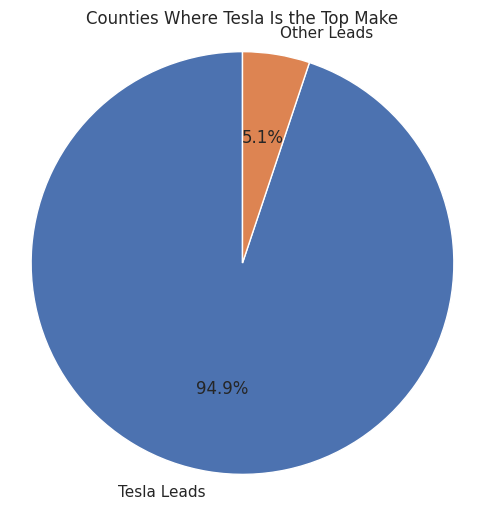

,County
6,Columbia
11,Garfield


In [ ]:
make_counts = filtered_df.groupby(['County', 'Make']).size().reset_index(name='Count')
top_makes_by_county = make_counts.sort_values(['County', 'Count'], ascending=[True, False])
top_makes_per_county = top_makes_by_county.groupby('County').first().reset_index()

top_makes_per_county["Tesla_Lead"] = top_makes_per_county["Make"]=="TESLA"
counts = top_makes_per_county["Tesla_Lead"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index.map({True: "Tesla Leads", False: "Other Leads"}), autopct="%1.1f%%", startangle=90)
plt.title("Counties Where Tesla Is the Top Make")
plt.axis("equal")  # Equal aspect ratio ensures the pie chart is a circle
plt.show()

display(top_makes_per_county[top_makes_per_county["Tesla_Lead"] == False]["County"])

In [ ]:
count_df = filtered_df[["County", "Make", "Model"]].groupby(["County","Make"]).count()
count_df = count_df.rename(columns={"Model": "Model_Count"})
count_df = count_df.sort_values(by=["County", "Model_Count"], ascending=[True, False])
# display(count_df)

counties = top_makes_per_county[top_makes_per_county["Make"]!="TESLA"]["County"]
for county in counties:
  print("County: ",county)
  display(count_df.loc[county])
  print("\n\n")

County:  Columbia


,Model_Count
Make,
FORD,5
TESLA,5
CHEVROLET,4
TOYOTA,2
GMC,1
KIA,1
MERCEDES-BENZ,1
MITSUBISHI,1
VOLKSWAGEN,1





County:  Garfield


,Model_Count
Make,
FORD,2
TOYOTA,1


# Top model per county


Top Models in Each County:


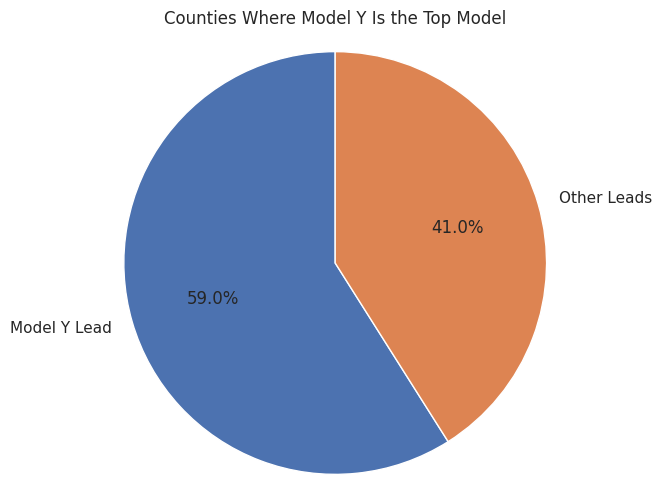

,County,Make,Model,Count,Model_Y_Lead
0,Adams,TESLA,MODEL 3,23,False
1,Asotin,TESLA,MODEL 3,11,False
2,Benton,TESLA,MODEL 3,576,False
6,Columbia,FORD,F-150,4,False
7,Cowlitz,TESLA,MODEL 3,186,False
9,Ferry,TESLA,MODEL 3,9,False
10,Franklin,TESLA,MODEL 3,212,False
11,Garfield,FORD,C-MAX,2,False
13,Grays Harbor,TESLA,MODEL 3,109,False
15,Jefferson,NISSAN,LEAF,166,False


In [ ]:
model_counts = filtered_df.groupby(['County', "Make", 'Model']).size().reset_index(name='Count')
top_models_by_county = model_counts.sort_values(['County', 'Count'], ascending=[True, False])
top_models_per_county = top_models_by_county.groupby('County').first().reset_index()

print("\nTop Models in Each County:")
# display(top_models_per_county.sort_values(by="Count", ascending=False).head(10))

top_models_per_county["Model_Y_Lead"] = top_models_per_county["Model"]=="MODEL Y"
counts = top_models_per_county["Model_Y_Lead"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index.map({True: "Model Y Lead", False: "Other Leads"}), autopct="%1.1f%%", startangle=90)
plt.title("Counties Where Model Y Is the Top Model")
plt.axis("equal")  # Equal aspect ratio ensures the pie chart is a circle
plt.show()

display(top_models_per_county[top_models_per_county["Model_Y_Lead"] == False])

# Make per County (crosstab)

In [ ]:
import pandas as pd

# Step 1: Count makes per county
make_counts = df.groupby(['County', 'Make']).size().reset_index(name='Count')

# Step 2: Get top 10 counties by total vehicle count
top_counties = (
    make_counts.groupby('County')['Count'].sum()
    .nlargest(10)
    .index
)

# Step 3: Filter to only include top counties
filtered_counts = make_counts[make_counts['County'].isin(top_counties)]

# Step 4: Get top 10 makes across the top counties
top_makes = (
    filtered_counts.groupby('Make')['Count'].sum()
    .nlargest(10)
    .index
)

# Step 5: Filter to only include top makes
filtered_counts = filtered_counts[filtered_counts['Make'].isin(top_makes)]

# Step 6: Create a crosstab (County x Make with Count as values)
crosstab = pd.crosstab(
    index=filtered_counts['County'],
    columns=filtered_counts['Make'],
    values=filtered_counts['Count'],
    aggfunc='sum',
    dropna=False
).fillna(0).astype(int)

# Display the crosstab
display(crosstab)


Make,BMW,CHEVROLET,FORD,HYUNDAI,JEEP,KIA,NISSAN,RIVIAN,TESLA,TOYOTA
County,,,,,,,,,,
Benton,134,292,260,78,93,143,141,46,1354,205
Clark,545,1095,802,501,577,771,869,303,5983,1109
King,5984,7181,4958,4001,3069,5327,7492,4124,55845,3836
Kitsap,332,761,520,332,248,553,714,379,2555,371
Pierce,746,1598,1419,601,502,1297,1271,674,8077,763
Skagit,68,341,200,132,79,160,179,161,928,156
Snohomish,1055,1847,1663,961,586,1366,2005,701,14875,908
Spokane,283,524,502,171,356,405,325,116,2461,310
Thurston,208,1182,869,282,202,619,656,130,2862,480


# Eligibility analysis

In [ ]:
feature = "Clean Alternative Fuel Vehicle (CAFV) Eligibility"

# Ensure the feature is a properly ordered categorical variable
df[feature] = pd.Categorical(df[feature], categories=df[feature].unique(), ordered=True)

# Step 1: Get Make counts per category
make_counts = (
    df.groupby(feature)["Make"]
    .value_counts()
    .reset_index(name="Count")
)

# Step 2: Rank within each group and keep top 3
make_counts["Rank"] = make_counts.groupby(feature)["Count"].rank(method="first", ascending=False).astype(int)

top_3 = (
    make_counts[make_counts["Rank"] <= 3]
    .sort_values([feature, "Rank"])
    .set_index([feature, "Rank"])
    [["Make", "Count"]]
)

# Step 3: Calculate mean range per Make per category
mean_range = (
    df.groupby([feature, "Make"])["Electric Range"]
    .mean()
    .reset_index(name="Mean Range")
)

# Step 4: Merge with top_3
top_3 = top_3.reset_index().merge(mean_range, on=[feature, "Make"]).set_index([feature, "Rank"])

display(top_3)


<ipython-input-30-2284640386>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(feature)["Make"]
<ipython-input-30-2284640386>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  make_counts["Rank"] = make_counts.groupby(feature)["Count"].rank(method="first", ascending=False).astype(int)
<ipython-input-30-2284640386>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([feature, "Make"])["Electric Range"]

Make  Count  \
Clean Alternative Fuel Vehicle (CAFV) Eligibility  Rank                     
Clean Alternative Fuel Vehicle Eligible            1         TESLA  25325   
                                                   2        NISSAN  10291   
                                                   3     CHEVROLET  10098   
Eligibility unknown as battery range has not be... 1         TESLA  78773   
                                                   2          FORD   9165   
                                                   3     CHEVROLET   7673   
Not eligible due to low battery range              1          JEEP   6652   
                                                   2        TOYOTA   3720   
                                                   3          FORD   3136   

                                                         Mean Range  
Clean Alternative Fuel Vehicle (CAFV) Eligibility  Rank              
Clean Alternative Fuel Vehicle Eligible            1     241.144363  
                                                   2     105.714216  
                                                   3     148.228164  
Eligibility unknown as battery range has not be... 1       0.000000  
                                                   2       0.000000  
                                                   3       0.000000  
Not eligible due to low battery range              1      22.277360  
                                                   2      20.112097  
                                                   3      19.836097

# Vehicles Count of Top 3 Make for each CAFV Eligibility
Conclusion:
- Most unknown eligibility are TESLA vehicles.
- Most eligible vehicles are by Tesla
- Most not eligible vehicles are by Jeep

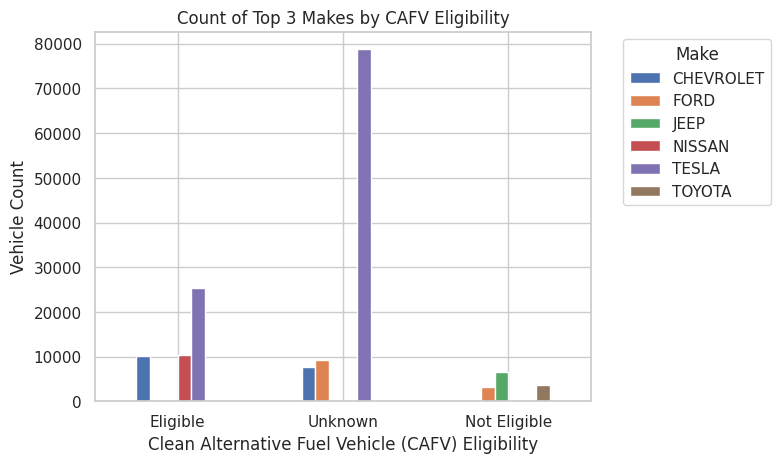

In [ ]:
# Multivariate
# Reset index so we can pivot
top_3_reset = top_3.reset_index()

# Pivot table: Rows = CAFV eligibility, Columns = Make, Values = Count
count_pivot = top_3_reset.pivot_table(index=feature, columns="Make", values="Count", observed=False)

# Plot
ax = count_pivot.plot.bar()

# Legend and labels
ax.set_title("Count of Top 3 Makes by CAFV Eligibility")
ax.set_ylabel("Vehicle Count")
ax.legend(title="Make", bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside if needed
ax.set_xticklabels(["Eligible", "Unknown", "Not Eligible"], rotation=0);


# Mean of Top 3 Make of each CAFV Eligibility
Conclusion:  
- TESLA has the highest mean of Electric Range
- Unknown eligibility has no known electric range.
- Low battery not eligibility vehicles have lower electric range than eligible vehicles

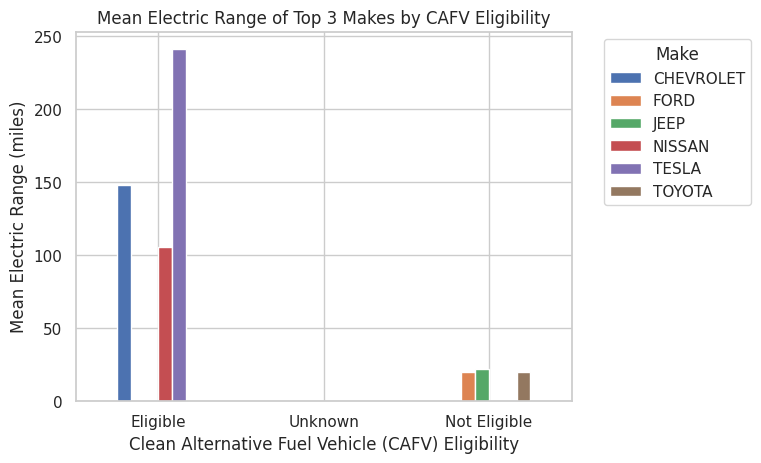

In [ ]:
# Multivariate
# Pivot table: Rows = CAFV eligibility, Columns = Make, Values = Mean Range
mean_range_pivot = top_3_reset.pivot_table(index=feature, columns="Make", values="Mean Range", observed=False)

# Plot
ax = mean_range_pivot.plot.bar()

# Legend and labels
ax.set_title("Mean Electric Range of Top 3 Makes by CAFV Eligibility")
ax.set_ylabel("Mean Electric Range (miles)")
ax.legend(title="Make", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(["Eligible", "Unknown", "Not Eligible"], rotation=0);


# Most models in each category

In [ ]:
feature = "Clean Alternative Fuel Vehicle (CAFV) Eligibility"

# Ensure the feature is a properly ordered categorical variable
df[feature] = pd.Categorical(df[feature], categories=df[feature].unique(), ordered=True)

# Step 1: Get Make counts per category
model_counts = (
    df.groupby([feature, "Make"])["Model"]
    .value_counts()
    .reset_index(name="Count")
)

# Step 2: Rank within each group and keep top X
max_size = 5
model_counts["Rank"] = model_counts.groupby(feature)["Count"].rank(method="first", ascending=False).astype(int)

top_df = (
    model_counts[model_counts["Rank"] <= max_size]
    .sort_values([feature, "Rank"])
    .set_index([feature, "Rank"])
    [["Make", "Model", "Count"]]
)

# Step 3: Calculate mean range per Make per category
mean_range = (
    df.groupby([feature, "Make", "Model"])["Electric Range"]
    .mean()
    .reset_index(name="Mean Range")
)


# Step 4: Merge with top_3
top_df = top_df.reset_index().merge(mean_range, on=[feature, "Make", "Model"]).set_index([feature, "Rank"])

display(top_df)


<ipython-input-33-2211984278>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([feature, "Make"])["Model"]
<ipython-input-33-2211984278>:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_counts["Rank"] = model_counts.groupby(feature)["Count"].rank(method="first", ascending=False).astype(int)
<ipython-input-33-2211984278>:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([feature, "Make", "Mode

Make  \
Clean Alternative Fuel Vehicle (CAFV) Eligibility  Rank               
Clean Alternative Fuel Vehicle Eligible            1          TESLA   
                                                   2         NISSAN   
                                                   3          TESLA   
                                                   4      CHEVROLET   
                                                   5      CHEVROLET   
Eligibility unknown as battery range has not be... 1          TESLA   
                                                   2          TESLA   
                                                   3           FORD   
                                                   4     VOLKSWAGEN   
                                                   5        HYUNDAI   
Not eligible due to low battery range              1           JEEP   
                                                   2         TOYOTA   
                                                   3           FORD   
                                                   4           JEEP   
                                                   5           FORD   

                                                                  Model  \
Clean Alternative Fuel Vehicle (CAFV) Eligibility  Rank                   
Clean Alternative Fuel Vehicle Eligible            1            MODEL 3   
                                                   2               LEAF   
                                                   3            MODEL S   
                                                   4            BOLT EV   
                                                   5               VOLT   
Eligibility unknown as battery range has not be... 1            MODEL Y   
                                                   2            MODEL 3   
                                                   3     MUSTANG MACH-E   
                                                   4               ID.4   
                                                   5            IONIQ 5   
Not eligible due to low battery range              1           WRANGLER   
                                                   2        PRIUS PRIME   
                                                   3             FUSION   
                                                   4     GRAND CHEROKEE   
                                                   5              C-MAX   

                                                         Count  Mean Range  
Clean Alternative Fuel Vehicle (CAFV) Eligibility  Rank                     
Clean Alternative Fuel Vehicle Eligible            1     13832  238.157750  
                                                   2     10291  105.714216  
                                                   3      5810  227.915835  
                                                   4      5168  244.631579  
                                                   5      4701   45.474154  
Eligibility unknown as battery range has not be... 1     48679    0.000000  
                                                   2     23275    0.000000  
                                                   3      5333    0.000000  
                                                   4      5089    0.000000  
                                                   5      4346    0.000000  
Not eligible due to low battery range              1      4989   21.369814  
                                                   2      2763   25.000000  
                                                   3      1689   20.400829  
                                                   4      1663   25.000000  
                                                   5      1447   19.176918

In [ ]:
def display_models_per_make_eligibility(category, title_category):
  # Filter for the "Unknown" category
  unknown_df = top_df.reset_index()
  unknown_df = unknown_df[unknown_df[feature] == category]

  # Create a label for each bar to show Make + Model
  unknown_df["Label"] = unknown_df["Make"] + " " + unknown_df["Model"]

  plt.figure(figsize=(12, 6))

  # Grouped bar plot: x=Make, hue=Model
  sns.barplot(
      data=unknown_df,
      x="Make",
      y="Count",
      hue="Model",
      palette="tab10"
  )

  plt.title(f"Top Models per Make in CAFV Category: {title_category}")
  plt.xlabel("Make")
  plt.ylabel("Number of Vehicles")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.legend(title="Model")
  plt.show()

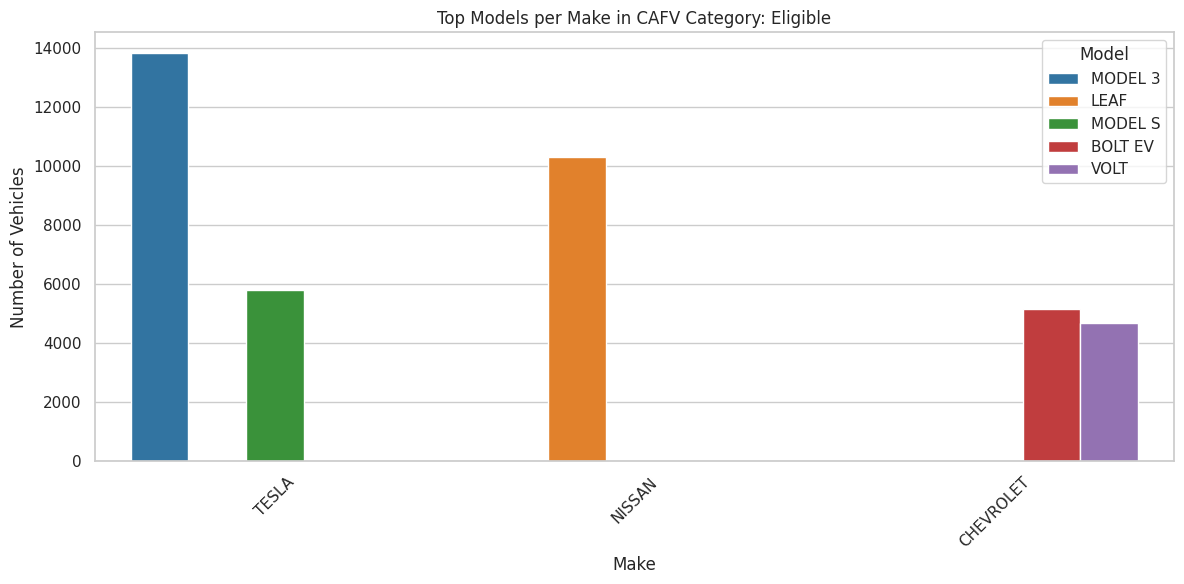

In [ ]:
display_models_per_make_eligibility("Clean Alternative Fuel Vehicle Eligible", "Eligible")

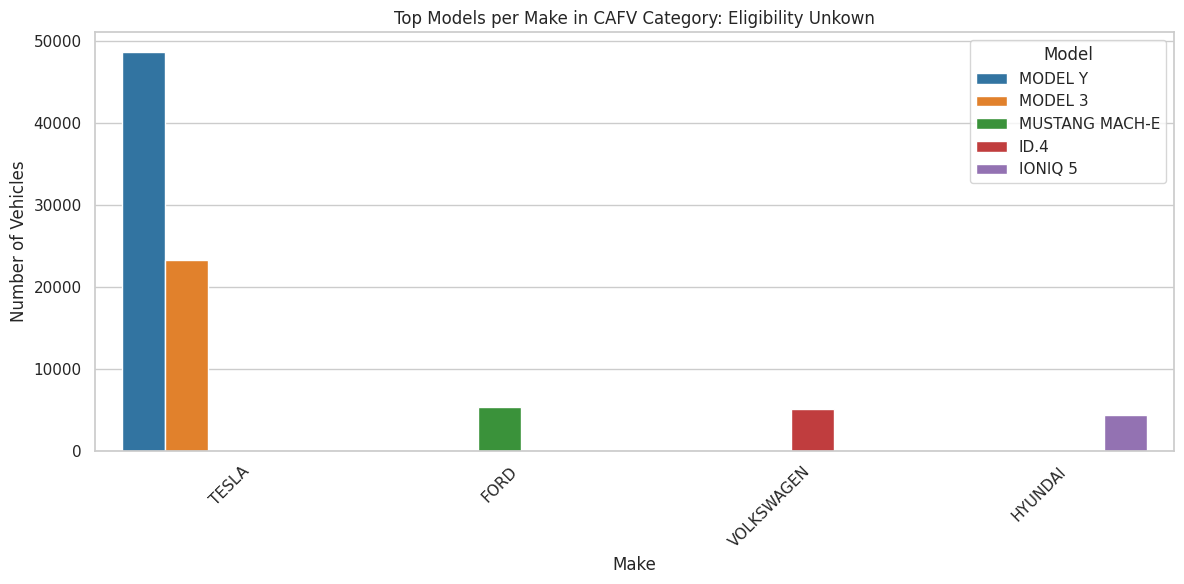

In [ ]:
display_models_per_make_eligibility("Eligibility unknown as battery range has not been researched", "Eligibility Unkown")

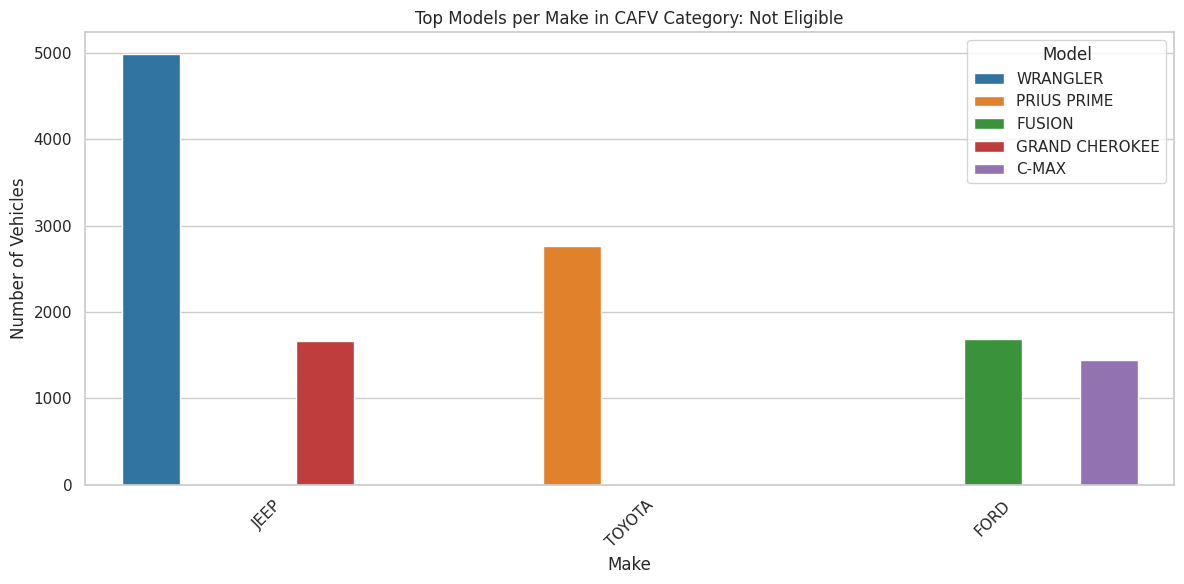

In [ ]:
display_models_per_make_eligibility("Not eligible due to low battery range", "Not Eligible")